# Supermarket sample (Kaggle) — Impact Split with step trace

This notebook applies `impact-split` to [Sample Supermarket](https://www.kaggle.com/datasets/bravehart101/sample-supermarket-dataset) and shows how the three core formulas behave on real data.

It loads data via `kagglehub`, builds a categorical **`X_df`** (strings per column) and additive `y`, fits `ImpactSplitter` with `trace=True` (the splitter factorizes columns internally), and diagnoses outcomes such as root stopping (`stop_reason`), `delta` vs per-category sums, and `delta_pct` sweeps using trace tables aligned with `impact_split.splitter`.

## Inspiration: the three-act design in one minute

`impact-split` was built for additive business KPIs where totals matter more than average purity.

1. **Act I (local sieve):** `delta = V_node * delta_pct` defines Positive/Neutral/Negative routing relative to local node volume.
2. **Act II (gain):** `Gain(X_i) = |S_P|/k_P + |S_N|/k_N` rewards material outer-branch impact while penalizing high-cardinality slicing.
3. **Act III (dual materiality stop):** branch positive and negative mass are compared to separate global pools (`V_global_P`, `V_global_N`) and splitting halts when both are immaterial.

As you read each diagnostic below, map it back to one of these three formulas.

## Prerequisites

- Install project deps: `pip install -r requirements.txt` (includes `kagglehub`).
- **Kaggle credentials:** for downloads, configure the Kaggle API (e.g. `~/.kaggle/kaggle.json` from your Kaggle account **Account → API → Create New Token**) or run `kagglehub.login()` once in an interactive session. See [kagglehub authentication](https://github.com/Kaggle/kagglehub#authentication).
- Target Python **3.13.x** as in `pyproject.toml`.

In [1]:
%matplotlib inline

from pathlib import Path

import kagglehub
import pandas as pd

from impact_split import ImpactSplitter

DATASET_SLUG = "bravehart101/sample-supermarket-dataset"
root = Path(kagglehub.dataset_download(DATASET_SLUG))
csv_paths = sorted(root.rglob("*.csv"))
assert csv_paths, f"No CSV under {root}"
csv_path = csv_paths[0]
print("Using:", csv_path)

2026-03-27 19:55:41.026 | INFO     | impact_split.config:<module>:11 - PROJ_ROOT path is: /Users/juedimyroeugenio/Documents/Projects/impact-split


Using: /Users/juedimyroeugenio/.cache/kagglehub/datasets/bravehart101/sample-supermarket-dataset/versions/1/SampleSuperstore.csv


In [2]:
df = pd.read_csv(csv_path)
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Build `X_df` and `y`

- **y:** `Profit` (additive contribution at row level).
- **X_df:** a few categorical columns (as strings) with moderate cardinality so the tree stays readable. City / postal code are omitted here; `ImpactSplitter.fit` factorizes each column internally.

In [3]:
import numpy as np

feature_cols = ["Region", "Category", "Segment", "Ship Mode"]
missing = [c for c in feature_cols + ["Profit"] if c not in df.columns]
if missing:
    raise ValueError(f"Unexpected columns: {missing}")

X_df = df[feature_cols].astype(str)
y_series = df["Profit"].astype(float)
mask = y_series.notna() & X_df.notna().all(axis=1)
X_df = X_df.loc[mask].reset_index(drop=True)
y_series = y_series.loc[mask].reset_index(drop=True)

y = y_series.to_numpy(dtype=np.float64)

print("rows:", X_df.shape[0], "X_df.shape:", X_df.shape, "y.sum():", float(y.sum()))
pd.DataFrame({c: X_df[c] for c in feature_cols}).head(), y[:5]

rows: 9994 X_df.shape: (9994, 4) y.sum(): 286397.0217


(  Region         Category    Segment       Ship Mode
 0  South        Furniture   Consumer    Second Class
 1  South        Furniture   Consumer    Second Class
 2   West  Office Supplies  Corporate    Second Class
 3  South        Furniture   Consumer  Standard Class
 4  South  Office Supplies   Consumer  Standard Class,
 array([  41.9136,  219.582 ,    6.8714, -383.031 ,    2.5164]))

In [4]:
model = ImpactSplitter(
    delta_pct=0.05,
    min_global_impact_pct=0.01,
    max_depth=4,
)
model.fit(X_df, y, trace=True)
# Integer matrix and per-column label arrays (same encoding as the splitter).
X = model._X
encoders = {c: np.asarray(m) for c, m in zip(model.feature_names_in_, model.category_maps_)}
print("trace steps:", len(model.fit_trace_))
print("root stop_reason:", model.fit_trace_[0].get("stop_reason"))

trace steps: 9
root stop_reason: None


## Root stop: diagnosis and EDA

`ImpactSplitter` records **why** a node becomes a leaf in `fit_trace_[0]["stop_reason"]` after `fit(..., trace=True)`. Order of checks in `_build`: **materiality** (both global triggers false) → **max_depth** → **identical_rows** → **no_split** (no feature with positive gain). At every depth, assignment uses `delta = V_node * delta_pct` (no special root rule).

Below: map the root step to that logic, compare **max |S_cat|** per feature to **delta**, and sweep **`delta_pct`** to see when splits appear.

root stop_reason: None
  positive_trigger: True   negative_trigger: True
  depth: 0   max_depth: 4
  action: split
  → (unexpected)

Per-feature max |S_cat| vs delta (root):


,feature,max_abs_S_cat,delta,all_categories_neutral
0,Region,108418.4489,29932.979655,False
1,Category,145454.9481,29932.979655,False
2,Segment,134119.2092,29932.979655,False
3,Ship Mode,164088.7875,29932.979655,False


If max |S_cat| < delta for every feature → guaranteed no_split at root.

Candidate gains at root:


,feature_index,gain,gain_P,gain_N,k_P,k_N
0,1,133972.874450,133972.874450,0.0,2,0
1,2,95465.673900,95465.673900,0.0,3,0
2,3,90168.420933,90168.420933,0.0,3,0
3,0,71599.255425,71599.255425,0.0,4,0



Sweep delta_pct (geomspace 1e-4 to 0.05):


,delta_pct,delta,trace_steps,root_stop_reason,root_action
0,0.000100,59.865959,5,None,split
1,0.000176,105.327277,5,None,split
2,0.000310,185.311241,5,None,split
3,0.000545,326.033837,5,None,split
4,0.000958,573.619074,5,None,split
5,0.001686,1009.216852,5,None,split
6,0.002966,1775.601090,5,None,split
7,0.005218,3123.966101,5,None,split
8,0.009181,5496.259408,5,None,split
9,0.016153,9670.036905,5,None,split


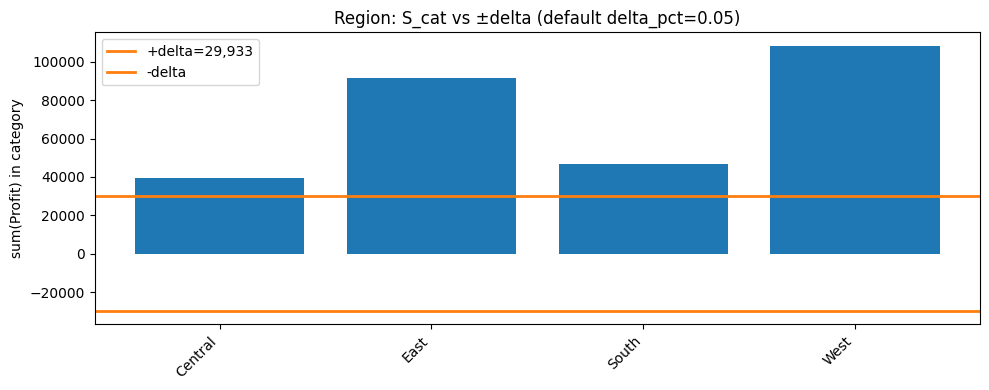

In [5]:
# 1) Map root trace entry to stop_reason (see impact_split.splitter._build)
root = model.fit_trace_[0]
sr = root.get("stop_reason")
print("root stop_reason:", sr)
print("  positive_trigger:", root["positive_trigger"], "  negative_trigger:", root["negative_trigger"])
print("  depth:", root["depth"], "  max_depth:", model.max_depth)
print("  action:", root["action"])

if sr == "materiality":
    print("  → Both global materiality ratios are below min_global_impact_pct (no positive and no negative trigger).")
elif sr == "max_depth":
    print("  → depth == max_depth at this node (e.g. max_depth=0 stops immediately after materiality).")
elif sr == "identical_rows":
    print("  → All rows in X_sub are identical (no feature to discriminate).")
elif sr == "no_split":
    print("  → No feature has total_gain > 0: every category sum S_cat lies in (-delta, +delta), so k_P=k_N=0 for gain.")
else:
    print("  → (unexpected)")

# 2) Per-feature max |S_cat| vs delta at root (same bincount logic as the splitter)
V_node = float(np.abs(y).sum())
delta = V_node * model.delta_pct
rows_eda = []
for j, col in enumerate(feature_cols):
    col_vals = X[:, j]
    max_cat = int(col_vals.max(initial=0))
    cat_sums = np.bincount(col_vals, weights=y, minlength=max_cat + 1)
    max_abs = float(np.max(np.abs(cat_sums)))
    rows_eda.append(
        {
            "feature": col,
            "max_abs_S_cat": max_abs,
            "delta": delta,
            "all_categories_neutral": max_abs < delta,
        }
    )
eda_vs_delta = pd.DataFrame(rows_eda)
print("\nPer-feature max |S_cat| vs delta (root):")
display(eda_vs_delta)
print("If max |S_cat| < delta for every feature → guaranteed no_split at root.")

# 3) Candidate gains at root (from trace)
cg0 = pd.DataFrame(root.get("candidate_gains", []))
print("\nCandidate gains at root:")
display(cg0)

# 4) Sweep delta_pct: trace length and root stop_reason
sweep_rows = []
for dp in np.geomspace(1e-4, 0.05, num=12):
    m = ImpactSplitter(
        delta_pct=float(dp),
        min_global_impact_pct=model.min_global_impact_pct,
        max_depth=model.max_depth,
    )
    m.fit(X_df, y, trace=True)
    r0 = m.fit_trace_[0]
    sweep_rows.append(
        {
            "delta_pct": float(dp),
            "delta": float(np.abs(y).sum() * dp),
            "trace_steps": len(m.fit_trace_),
            "root_stop_reason": r0.get("stop_reason"),
            "root_action": r0["action"],
        }
    )
sweep_df = pd.DataFrame(sweep_rows)
print("\nSweep delta_pct (geomspace 1e-4 to 0.05):")
display(sweep_df)

# 5) Bar chart: first feature — category sums vs ±delta (default model.delta_pct)
import matplotlib.pyplot as plt

fi = 0
col_vals = X[:, fi]
max_cat = int(col_vals.max(initial=0))
cat_sums = np.bincount(col_vals, weights=y, minlength=max_cat + 1)
counts = np.bincount(col_vals, minlength=max_cat + 1)
present = np.flatnonzero(counts)
labels = [str(encoders[feature_cols[fi]][i]) for i in present]
plt.figure(figsize=(10, 4))
plt.bar(range(len(present)), cat_sums[present])
plt.axhline(delta, color="C1", linewidth=2, label=f"+delta={delta:,.0f}")
plt.axhline(-delta, color="C1", linewidth=2, label=f"-delta")
plt.xticks(range(len(present)), labels, rotation=45, ha="right")
plt.ylabel("sum(Profit) in category")
plt.title(f"{feature_cols[fi]}: S_cat vs ±delta (default delta_pct={model.delta_pct})")
plt.legend()
plt.tight_layout()
plt.show()

## Node-level thresholds and sums

At each node, `delta = delta_pct * V_node` (same at root and children). Categories are **P** if `S_cat > delta`, **N** if `S_cat < -delta`, else **neutral**. The table lists node mass, `delta`, materiality flags, and `stop_reason` for every trace step; per-feature category rows are in `category_tables` when present.

In [6]:
summary_rows = []
for step in model.fit_trace_:
    d = float(step["delta"])
    gr = step["global_ratios"]
    summary_rows.append(
        {
            "node_id": step["node_id"],
            "depth": step["depth"],
            "n_samples": step["n_samples"],
            "total_sum": step["total_sum"],
            "V_node": step["V_node"],
            "s_node_p": step["s_node_p"],
            "s_node_n": step["s_node_n"],
            "delta_pct": step["delta_pct"],
            "delta": d,
            "neutral_band": f"({-d:,.3f}, {d:,.3f})",
            "pos_ratio": gr["pos_ratio"],
            "neg_ratio": gr["neg_ratio"],
            "positive_trigger": step["positive_trigger"],
            "negative_trigger": step["negative_trigger"],
            "action": step["action"],
            "stop_reason": step.get("stop_reason"),
        }
    )
pd.DataFrame(summary_rows)

,node_id,depth,n_samples,total_sum,V_node,s_node_p,s_node_n,delta_pct,delta,neutral_band,pos_ratio,neg_ratio,positive_trigger,negative_trigger,action,stop_reason
0,node_0,0,9994,286397.0217,598659.5931,442528.3074,156131.2857,0.05,29932.979655,"(-29,932.980, 29,932.980)",1.000000,1.000000,True,True,split,NaN
1,node_1,1,7873,267945.7489,458336.1023,363140.9256,95195.1767,0.05,22916.805115,"(-22,916.805, 22,916.805)",0.820605,0.609712,True,True,split,NaN
2,node_2,2,7873,267945.7489,458336.1023,363140.9256,95195.1767,0.05,22916.805115,"(-22,916.805, 22,916.805)",0.820605,0.609712,True,True,split,NaN
3,node_3,3,7873,267945.7489,458336.1023,363140.9256,95195.1767,0.05,22916.805115,"(-22,916.805, 22,916.805)",0.820605,0.609712,True,True,split,NaN
4,node_4,4,7873,267945.7489,458336.1023,363140.9256,95195.1767,0.05,22916.805115,"(-22,916.805, 22,916.805)",0.820605,0.609712,True,True,leaf,max_depth
5,node_5,1,2121,18451.2728,140323.4908,79387.3818,60936.1090,0.05,7016.174540,"(-7,016.175, 7,016.175)",0.179395,0.390288,True,True,split,NaN
6,node_6,2,2121,18451.2728,140323.4908,79387.3818,60936.1090,0.05,7016.174540,"(-7,016.175, 7,016.175)",0.179395,0.390288,True,True,split,NaN
7,node_7,3,2121,18451.2728,140323.4908,79387.3818,60936.1090,0.05,7016.174540,"(-7,016.175, 7,016.175)",0.179395,0.390288,True,True,split,NaN
8,node_8,4,2121,18451.2728,140323.4908,79387.3818,60936.1090,0.05,7016.174540,"(-7,016.175, 7,016.175)",0.179395,0.390288,True,True,leaf,max_depth


## Trace: one row per decision node (pre-order)

Each entry includes `delta`, node masses (`V_node`, `s_node_p`, `s_node_n`, `total_sum`), `global_ratios`, `positive_trigger` / `negative_trigger`, `candidate_gains`, `chosen_feature_index` when splitting, and `category_tables` per feature (`S_cat` vs ±`delta`).

In [7]:
def _max_candidate_gain(step: dict) -> float | None:
    cgs = step.get("candidate_gains") or []
    if not cgs:
        return None
    return max(c["gain"] for c in cgs)


trace_rows = []
for step in model.fit_trace_:
    trace_rows.append(
        {
            "node_id": step["node_id"],
            "depth": step["depth"],
            "n_samples": step["n_samples"],
            "action": step["action"],
            "stop_reason": step.get("stop_reason"),
            "delta": step["delta"],
            "materiality_pass": step["positive_trigger"] or step["negative_trigger"],
            "chosen_feature_index": step.get("chosen_feature_index"),
            "max_candidate_gain": _max_candidate_gain(step),
        }
    )
pd.DataFrame(trace_rows)

,node_id,depth,n_samples,action,stop_reason,delta,materiality_pass,chosen_feature_index,max_candidate_gain
0,node_0,0,9994,split,NaN,29932.979655,True,1.0,133972.87445
1,node_1,1,7873,split,NaN,22916.805115,True,1.0,133972.87445
2,node_2,2,7873,split,NaN,22916.805115,True,1.0,133972.87445
3,node_3,3,7873,split,NaN,22916.805115,True,1.0,133972.87445
4,node_4,4,7873,leaf,max_depth,22916.805115,True,NaN,NaN
5,node_5,1,2121,split,NaN,7016.174540,True,1.0,18451.27280
6,node_6,2,2121,split,NaN,7016.174540,True,1.0,18451.27280
7,node_7,3,2121,split,NaN,7016.174540,True,1.0,18451.27280
8,node_8,4,2121,leaf,max_depth,7016.174540,True,NaN,NaN


In [8]:
shown = 0
for step in model.fit_trace_:
    if step["action"] != "split":
        continue
    fi = step.get("chosen_feature_index")
    print("=" * 80)
    print(step["node_id"], "depth", step["depth"], "split on feature_index", fi)
    cg = pd.DataFrame(step["candidate_gains"])
    print("Candidate gains:")
    display(cg)
    if fi is not None and fi in step.get("category_tables", {}):
        print("Category assignment (chosen feature):")
        display(pd.DataFrame(step["category_tables"][fi]))
    shown += 1
    if shown >= 3:
        print("... (truncated; increase `shown` limit to inspect more splits)")
        break

node_0 depth 0 split on feature_index 1
Candidate gains:


,feature_index,gain,gain_P,gain_N,k_P,k_N
0,1,133972.874450,133972.874450,0.0,2,0
1,2,95465.673900,95465.673900,0.0,3,0
2,3,90168.420933,90168.420933,0.0,3,0
3,0,71599.255425,71599.255425,0.0,4,0


Category assignment (chosen feature):


,category,S_cat,branch,category_label
0,0,18451.2728,neutral,Furniture
1,1,122490.8008,P,Office Supplies
2,2,145454.9481,P,Technology


node_1 depth 1 split on feature_index 1
Candidate gains:


...

node_2 depth 2 split on feature_index 1
Candidate gains:


,feature_index,gain,gain_P,gain_N,k_P,k_N
0,1,133972.874450,133972.874450,0.0,2,0
1,2,89315.249633,89315.249633,0.0,3,0
2,3,84283.779467,84283.779467,0.0,3,0
3,0,66986.437225,66986.437225,0.0,4,0


Category assignment (chosen feature):


,category,S_cat,branch,category_label
0,1,122490.8008,P,Office Supplies
1,2,145454.9481,P,Technology


... (truncated; increase `shown` limit to inspect more splits)


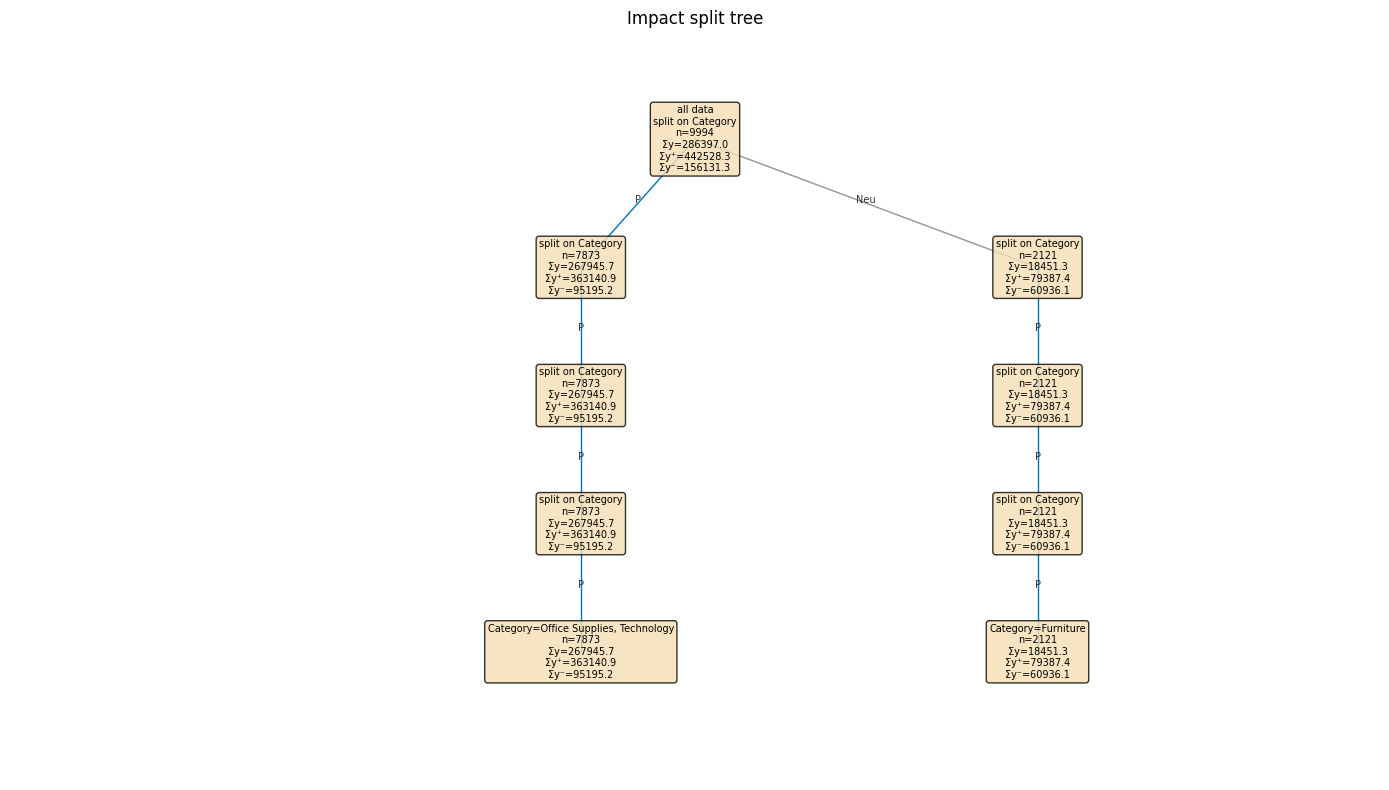

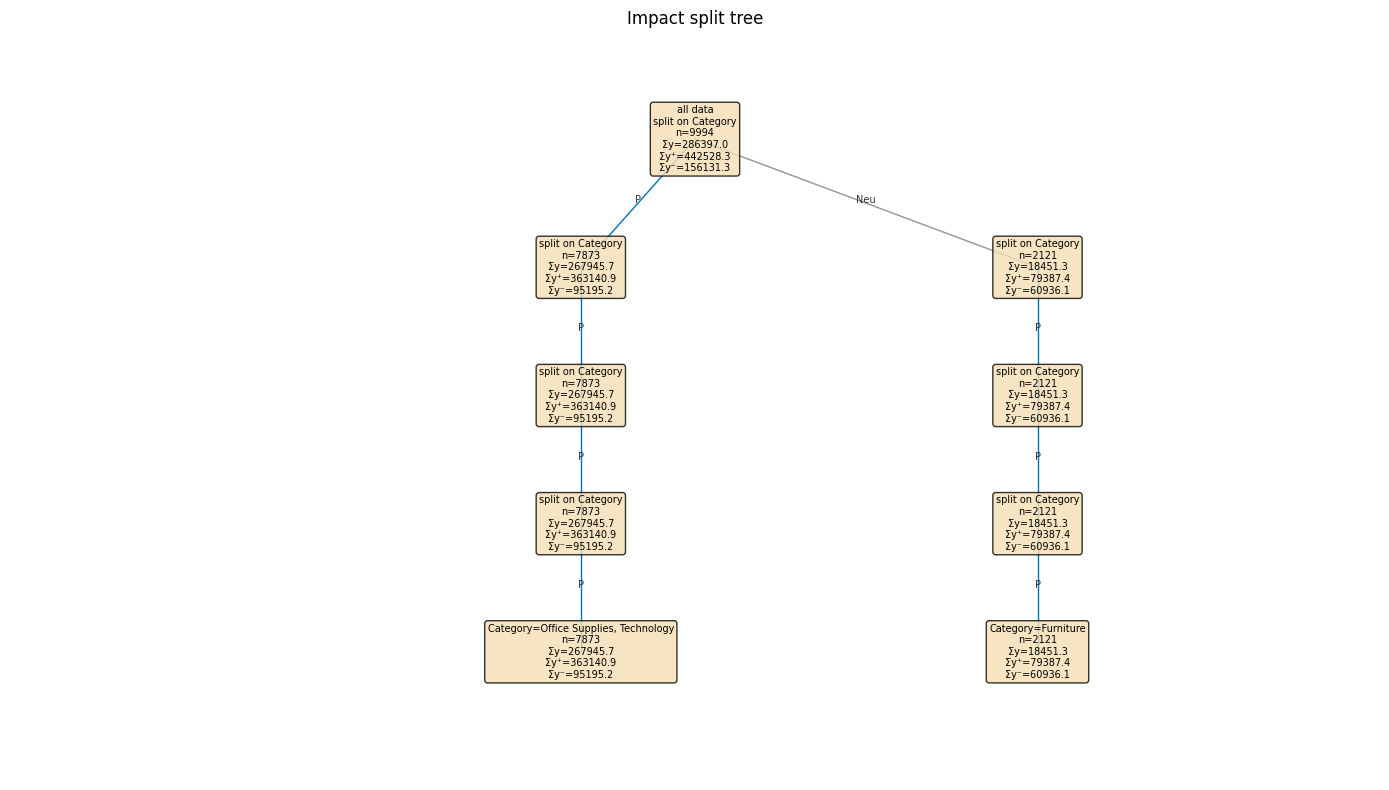

In [9]:
model.plot_tree(figsize=(14, 8))

`plot_tree` renders one matplotlib figure: each node shows its segment line (`all data` or `feature=categories`), internal nodes add `split on <feature>`, plus `n` and Σy stats everywhere.

In [10]:
segments = model.get_impact_segments()
segments.head(15)

,path,total_sum,n_samples,node_id
0,"root / Category=Office Supplies, Technology / ...",267945.7489,7873,node_4
1,root / Category=Furniture / Category=Furniture...,18451.2728,2121,node_8


## Sanity checks

- Terminal segments partition the rows: the sum of segment `total_sum` should match the global sum of `y` (each row assigned to exactly one leaf).
- Root trace step should show `depth == 0` and `global_ratios` consistent with the node’s share of positive vs negative mass.
- **Root-only tree with `no_split`:** usually `delta_pct * V_node` is large vs per-category `|S_cat|` — lower `delta_pct` (see sweep above) or coarser `y` scaling. **`materiality`** at root is rare unless `min_global_impact_pct` is extreme or `y` has no positive or negative mass globally.

In [11]:
seg_sum = segments["total_sum"].sum()
y_sum = float(y.sum())
print("sum(y):", y_sum)
print("sum(segment totals):", seg_sum)
assert abs(seg_sum - y_sum) < 1e-3 * max(1.0, abs(y_sum)), "Segment totals should match global y sum"

sum(y): 286397.0217
sum(segment totals): 286397.02170000004
